# Preparar los datos

Aquí limpiamos y arreglamos los datos para que el modelo pueda aprender bien.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
df = pd.read_csv('../data/raw/BankChurners.csv')
df = df.iloc[:, :-2]
df = df.drop('CLIENTNUM', axis=1)
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Sacamos CLIENTNUM. No sirve para nada. Es solo un ID, el modelo no necesita eso.

Convertir variables categóricas

In [12]:
df_proc = df.copy()
df_proc['Attrition_Flag'] = df_proc['Attrition_Flag'].map({'Existing Customer':0,'Attrited Customer':1})

le = LabelEncoder()
for col in ['Gender','Marital_Status','Card_Category']:
    df_proc[col] = le.fit_transform(df_proc[col])

Attrition_Flag ahora es 0 (se queda) y 1 (se va). Así el modelo entiende probabilidades directamente.

Eliminar variables redundantes

In [13]:
numeric = df_proc.select_dtypes(include=np.number).drop('Attrition_Flag', axis=1)

vif = pd.DataFrame()
vif['Variable'] = numeric.columns
vif['VIF'] = [variance_inflation_factor(numeric.values, i) for i in range(len(numeric.columns))]
vif.sort_values(by='VIF', ascending=False)

c:\Users\monte\OneDrive\Documentos\ProjectML Churn\venv_clean\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
11,Avg_Open_To_Buy,inf
9,Credit_Limit,inf
10,Total_Revolving_Bal,inf
0,Customer_Age,75.784552
5,Months_on_book,56.444953
14,Total_Trans_Ct,23.772960
12,Total_Amt_Chng_Q4_Q1,13.992602
15,Total_Ct_Chng_Q4_Q1,11.827710
13,Total_Trans_Amt,8.715974
6,Total_Relationship_Count,7.518242


Hay variables con VIF infinito. Son clones matemáticos de otras variables. Hay que sacar una para que el modelo no se confunda.

In [14]:
df_proc = df_proc.drop('Avg_Open_To_Buy', axis=1)

Sacamos Avg_Open_To_Buy. Es solo Credit_Limit - Balance. Información redundante.

Dividir datos en entrenamiento y test

In [15]:
X = pd.get_dummies(df_proc.drop('Attrition_Flag', axis=1), drop_first=True)
y = df_proc['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

80/20. Y stratify=y mantiene la proporción de churn en ambos conjuntos. Si el total tiene 16% churn, train y test también tendrán 16%. Así el modelo entrenamos y evaluamos en condiciones justas.

Balancear las clases

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

pd.Series(y_train_res).value_counts()

Attrition_Flag
0    6799
1    6799
Name: count, dtype: int64

<Axes: xlabel='Attrition_Flag'>

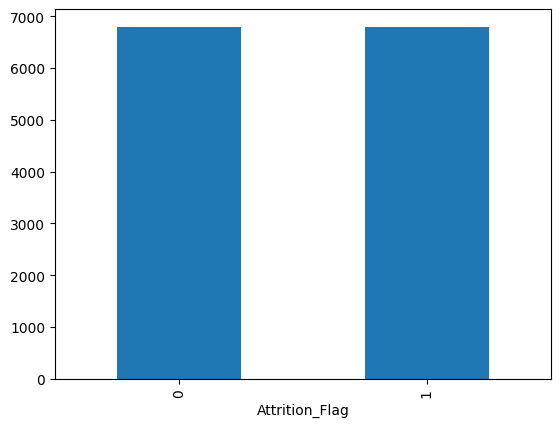

In [17]:
pd.Series(y_train_res).value_counts().plot(kind='bar')

SMOTE genera clientes sintéticos para igualar las clases. No sacamos clientes reales (eso perdería información del banco). Generamos sintéticos. Así el modelo aprende de ambas clases por igual.

## Distribución de Card_Category: Antes vs Después de SMOTE

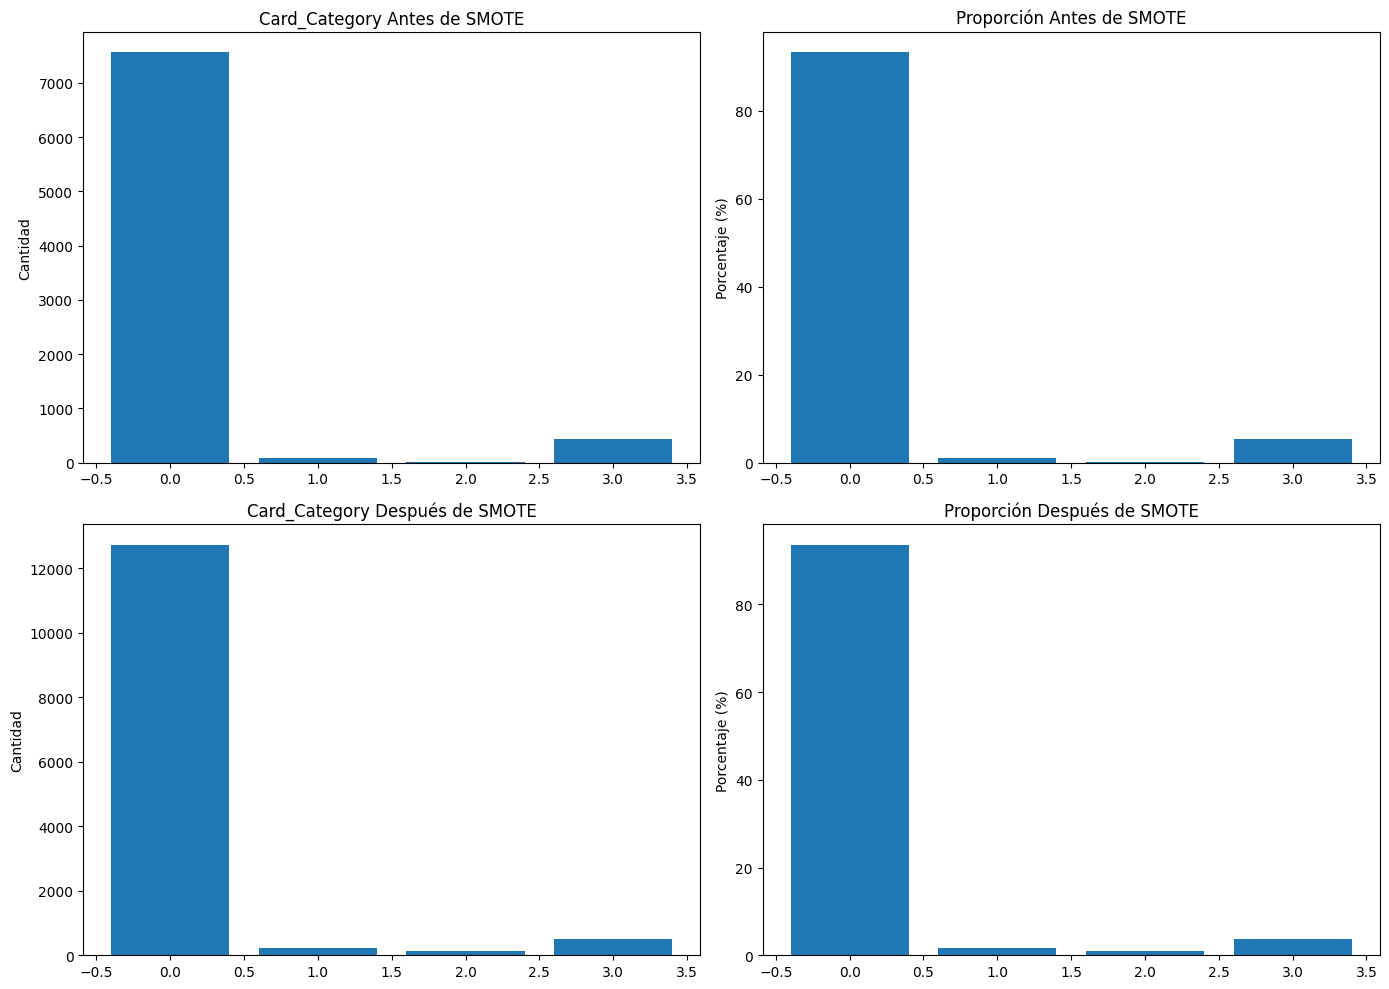

Antes de SMOTE:
Card_Category
0    7559
3     431
1      94
2      17
Name: count, dtype: int64

Card_Category
0    93.31
3     5.32
1     1.16
2     0.21
Name: proportion, dtype: float64

Después de SMOTE:
Card_Category
0    12726
3      502
1      239
2      131
Name: count, dtype: int64

Card_Category
0    93.59
3     3.69
1     1.76
2     0.96
Name: proportion, dtype: float64


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Antes de SMOTE
card_original = X_train['Card_Category'].value_counts()
axes[0,0].bar(card_original.index, card_original.values)
axes[0,0].set_title('Card_Category Antes de SMOTE')
axes[0,0].set_ylabel('Cantidad')

card_prop_original = X_train['Card_Category'].value_counts(normalize=True) * 100
axes[0,1].bar(card_prop_original.index, card_prop_original.values)
axes[0,1].set_title('Proporción Antes de SMOTE')
axes[0,1].set_ylabel('Porcentaje (%)')

# Después de SMOTE
card_res = X_train_res['Card_Category'].value_counts()
axes[1,0].bar(card_res.index, card_res.values)
axes[1,0].set_title('Card_Category Después de SMOTE')
axes[1,0].set_ylabel('Cantidad')

card_prop_res = X_train_res['Card_Category'].value_counts(normalize=True) * 100
axes[1,1].bar(card_prop_res.index, card_prop_res.values)
axes[1,1].set_title('Proporción Después de SMOTE')
axes[1,1].set_ylabel('Porcentaje (%)')

plt.tight_layout()
plt.show()

print("Antes de SMOTE:")
print(card_original)
print()
print(card_prop_original.round(2))
print()
print("Después de SMOTE:")
print(card_res)
print()
print(card_prop_res.round(2))

La mayoría usa Blue. Cuando SMOTE genera sintéticos, tiende a crear más Blue también (porque hay más datos de Blue). Eso está bien. Es la realidad del banco.

Resumen

- Eliminamos lo que no sirve (CLIENTNUM, variables redundantes)
- Codificamos variables categóricas
- Dividimos en entrenamiento/test (80/20)
- Balanceamos con SMOTE (16% → 50% churn en entrenamiento)
- 40 variables finales, listas para el modelo